# Cancelled Reservations Analysis: Who Cancels Them?

Analyzes **all** cancelled reservations across every contact group (NO CONTACT, HRD-OKC, COUNTER).

**Cancel source logic (from Translog):**
- `Edi-Cancel` with `EMP_LNAME='EDI'` → Insurance Partner (EDI), matched via `Knum`
- `Rez-Cancelled` with `LocCode != '12'` → Branch/Counter, matched via `REZ_NUM`
- `Rez-Cancelled` with `LocCode == '12'` → RCU, matched via `REZ_NUM`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hertz brand colors
HERTZ_YELLOW = '#F5C400'
CHARCOAL = '#1A1A1A'
DARK_GRAY = '#6E6E6E'
LIGHT_GRAY = '#E6E6E6'

## 1. Load Data

In [2]:
translog = pd.read_csv('../data/raw/Translog (Partitioned) Nov-Dec 2025.csv', low_memory=False)
print(f'Translog records: {len(translog):,}')

conv = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')
print(f'Conversion Data records: {len(conv):,}')

Translog records: 5,201,137


Conversion Data records: 68,360


## 2. Identify ALL Cancelled Reservations

In [3]:
all_cancelled = conv[conv['\nCANCEL_ID'] == 1].copy()
all_confirms = set(all_cancelled['\nCONFIRM_NUM'].astype(str).str.strip())
print(f'Total cancelled reservations: {len(all_confirms):,}')
print(f'\nBy contact group:')
print(all_cancelled['\nCONTACT_GROUP'].value_counts())

Total cancelled reservations: 13,702

By contact group:
\nCONTACT_GROUP
COUNTER       4785
HRD - OKC     4571
NO CONTACT    4346
Name: count, dtype: int64


## 3. Find Cancellation Events in Translog

In [4]:
# EDI cancellations — Insurance Partner (matched via Knum)
edi_cancels = translog[(translog['MSG1'] == 'Edi-Cancel') & (translog['EMP_LNAME'] == 'EDI')].copy()
edi_cancels['res_id'] = edi_cancels['Knum'].astype(str).str.strip()
edi_cancels = edi_cancels[edi_cancels['res_id'].isin(all_confirms)]
edi_cancels['cancel_source'] = 'Insurance Partner (EDI)'
print(f'EDI cancellations: {len(edi_cancels):,}')

# Rez-Cancelled — Branch/Counter or RCU (matched via REZ_NUM)
rez_cancels = translog[translog['MSG1'] == 'Rez-Cancelled'].copy()
rez_cancels['res_id'] = rez_cancels['REZ_NUM'].astype(str).str.strip()
rez_cancels = rez_cancels[rez_cancels['res_id'].isin(all_confirms)]
rez_cancels['cancel_source'] = rez_cancels['LocCode'].apply(
    lambda x: 'RCU' if str(x) == '12' else 'Branch/Counter'
)
print(f'Rez-Cancelled: {len(rez_cancels):,}')
print(rez_cancels['cancel_source'].value_counts())

# Combine
all_cancels = pd.concat([edi_cancels, rez_cancels], ignore_index=True)
print(f'\nTotal cancellation events: {len(all_cancels):,}')

EDI cancellations: 9,862


Rez-Cancelled: 3,042
cancel_source
Branch/Counter    2602
RCU                440
Name: count, dtype: int64

Total cancellation events: 12,904


## 4. Merge Contact Group & Calculate Time to Cancel

In [5]:
# Map confirm_num → contact group from conversion data
confirm_to_group = all_cancelled.set_index(
    all_cancelled['\nCONFIRM_NUM'].astype(str).str.strip()
)['\nCONTACT_GROUP'].to_dict()

all_cancels['contact_group'] = all_cancels['res_id'].map(confirm_to_group)
print('Cancel events by contact group:')
print(all_cancels['contact_group'].value_counts())

Cancel events by contact group:
contact_group
COUNTER       4593
HRD - OKC     4409
NO CONTACT    3902
Name: count, dtype: int64


In [6]:
# Parse timestamps
all_cancels['cancel_datetime'] = pd.to_datetime(
    all_cancels['SystemDate'].astype(str), format='%Y%m%d%H%M%S', errors='coerce'
)

translog['res_id'] = translog['Knum'].astype(str).str.strip()
translog['event_datetime'] = pd.to_datetime(
    translog['SystemDate'].astype(str), format='%Y%m%d%H%M%S', errors='coerce'
)

# First event per reservation = creation time
first_events = (
    translog[translog['res_id'].isin(all_confirms)]
    .groupby('res_id')['event_datetime'].min()
    .reset_index()
)
first_events.columns = ['res_id', 'creation_datetime']

# Merge and compute time delta
all_cancels = all_cancels.merge(first_events, on='res_id', how='left')
all_cancels['time_to_cancel_mins'] = (
    all_cancels['cancel_datetime'] - all_cancels['creation_datetime']
).dt.total_seconds() / 60

all_cancels = all_cancels[
    (all_cancels['time_to_cancel_mins'] > 0) & all_cancels['time_to_cancel_mins'].notna()
]
print(f'Records with valid time: {len(all_cancels):,}')

Records with valid time: 12,903


In [7]:
# Time buckets
def time_bucket(mins):
    if mins <= 10:
        return '0-10 min'
    elif mins <= 30:
        return '10-30 min'
    elif mins <= 60:
        return '30-60 min'
    elif mins <= 24 * 60:
        return '1-24 hours'
    else:
        return '>24 hours'

all_cancels['time_bucket'] = all_cancels['time_to_cancel_mins'].apply(time_bucket)

bucket_order = ['0-10 min', '10-30 min', '30-60 min', '1-24 hours', '>24 hours']
source_order = ['Insurance Partner (EDI)', 'Branch/Counter', 'RCU']

## 5. Aggregate

In [8]:
# --- Panel 1: Overall who cancels ---
who_overall = all_cancels.groupby('cancel_source').size().reindex(source_order).fillna(0).astype(int)
who_overall_pct = (who_overall / who_overall.sum() * 100).round(1)
print('Who Cancels (overall):')
for src in source_order:
    print(f'  {src}: {who_overall[src]:,} ({who_overall_pct[src]:.1f}%)')

# --- Panel 2: Who cancels by contact group ---
group_source = all_cancels.groupby(['contact_group', 'cancel_source']).size().unstack(fill_value=0)
group_source = group_source.reindex(columns=source_order, fill_value=0)
group_source_pct = group_source.div(group_source.sum(axis=1), axis=0) * 100
contact_group_order = ['NO CONTACT', 'HRD - OKC', 'COUNTER']
group_source_pct = group_source_pct.reindex(contact_group_order)
group_source = group_source.reindex(contact_group_order)
print('\nWho cancels by contact group (%):')
print(group_source_pct.round(1))

# --- Panel 3: Who cancels by time bucket ---
time_source = all_cancels.groupby(['time_bucket', 'cancel_source']).size().unstack(fill_value=0)
time_source = time_source.reindex(index=bucket_order, columns=source_order, fill_value=0)
time_source_pct = time_source.div(time_source.sum(axis=1), axis=0) * 100
time_source_totals = time_source.sum(axis=1)
print('\nWho cancels by time bucket (%):')
print(time_source_pct.round(1))

Who Cancels (overall):
  Insurance Partner (EDI): 9,862 (76.4%)
  Branch/Counter: 2,601 (20.2%)
  RCU: 440 (3.4%)

Who cancels by contact group (%):
cancel_source  Insurance Partner (EDI)  Branch/Counter  RCU
contact_group                                              
NO CONTACT                        90.0             5.5  4.6
HRD - OKC                         73.7            21.4  4.8
COUNTER                           67.5            31.4  1.1

Who cancels by time bucket (%):
cancel_source  Insurance Partner (EDI)  Branch/Counter   RCU
time_bucket                                                 
0-10 min                          98.5             1.3   0.3
10-30 min                         88.2             9.1   2.7
30-60 min                         77.1            10.5  12.4
1-24 hours                        79.1            15.1   5.7
>24 hours                         63.4            34.8   1.9


## 6. Chart — Who Cancels Them?

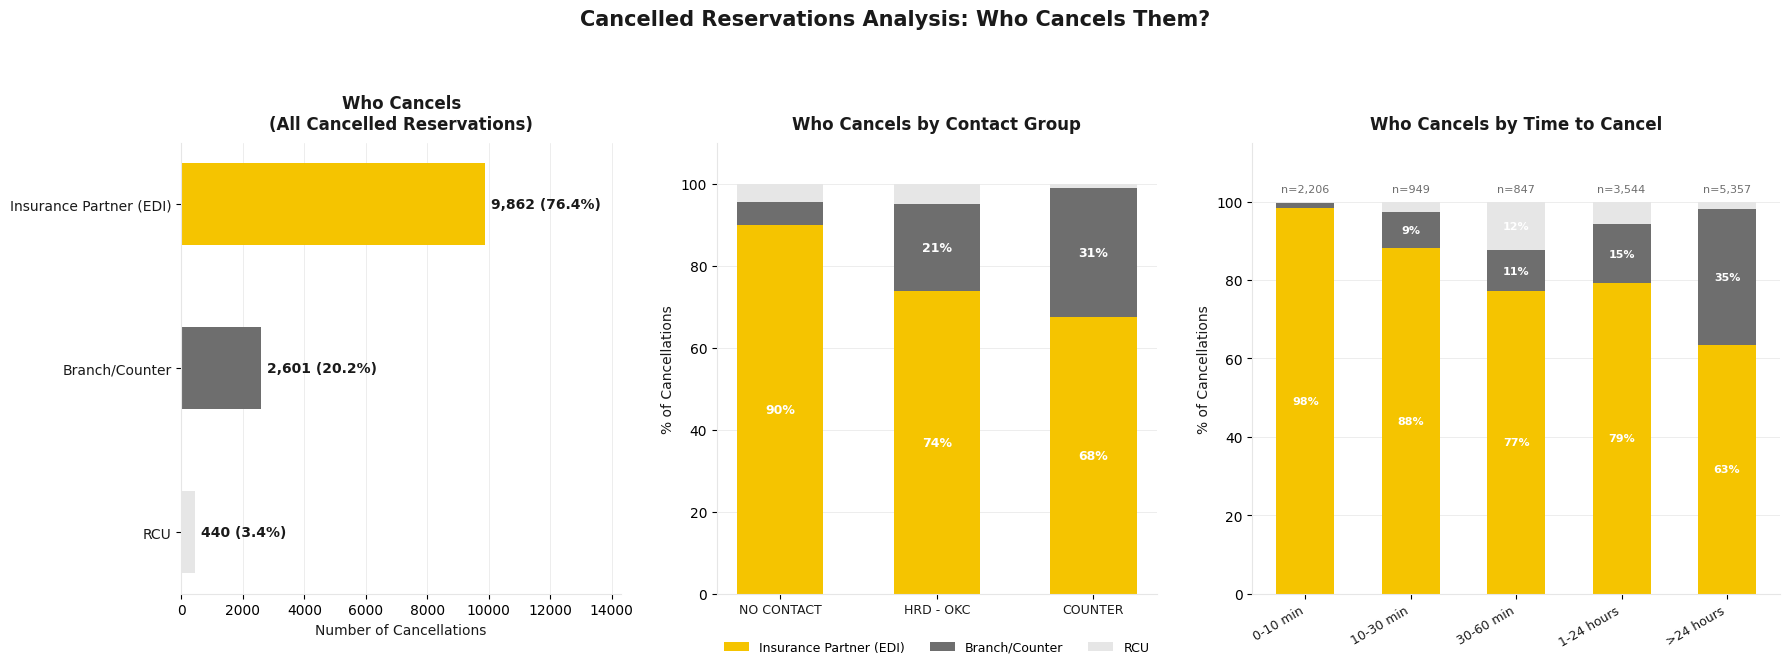

Saved to Charts/who_cancels_analysis.png


In [9]:
colors = {
    'Insurance Partner (EDI)': HERTZ_YELLOW,
    'Branch/Counter': DARK_GRAY,
    'RCU': LIGHT_GRAY,
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7),
                                     gridspec_kw={'width_ratios': [1, 1, 1.2]})
fig.patch.set_facecolor('white')

# ============ LEFT: Who Cancels (All) — horizontal bar ============
ax1.set_facecolor('white')
y_pos = np.arange(len(source_order))
vals = [who_overall[s] for s in source_order]
bar_colors = [colors[s] for s in source_order]

bars = ax1.barh(y_pos, vals, height=0.5, color=bar_colors)
for i, (bar, src) in enumerate(zip(bars, source_order)):
    count = who_overall[src]
    pct = who_overall_pct[src]
    ax1.text(bar.get_width() + max(vals) * 0.02, bar.get_y() + bar.get_height() / 2,
             f'{count:,} ({pct:.1f}%)', va='center', fontsize=10, color=CHARCOAL, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(source_order, fontsize=10, color=CHARCOAL)
ax1.set_xlabel('Number of Cancellations', fontsize=10, color=CHARCOAL)
ax1.set_title('Who Cancels\n(All Cancelled Reservations)', fontsize=12,
              fontweight='bold', color=CHARCOAL, pad=10)
ax1.set_xlim(0, max(vals) * 1.45)
ax1.xaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5)
ax1.set_axisbelow(True)
ax1.invert_yaxis()
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(LIGHT_GRAY)
ax1.spines['bottom'].set_color(LIGHT_GRAY)

# ============ MIDDLE: Who Cancels by Contact Group — stacked bar ============
ax2.set_facecolor('white')
x_pos = np.arange(len(contact_group_order))
bottom = np.zeros(len(contact_group_order))

for src in source_order:
    values = [group_source_pct.loc[g, src] for g in contact_group_order]
    ax2.bar(x_pos, values, width=0.55, bottom=bottom, color=colors[src], label=src)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val >= 6:
            ax2.text(x_pos[i], bot + val / 2, f'{val:.0f}%',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom = bottom + np.array(values)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(contact_group_order, fontsize=9, color=CHARCOAL)
ax2.set_ylabel('% of Cancellations', fontsize=10, color=CHARCOAL)
ax2.set_title('Who Cancels by Contact Group', fontsize=12,
              fontweight='bold', color=CHARCOAL, pad=10)
ax2.set_ylim(0, 110)
ax2.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5)
ax2.set_axisbelow(True)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(LIGHT_GRAY)
ax2.spines['bottom'].set_color(LIGHT_GRAY)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=9)

# ============ RIGHT: Who Cancels by Time to Cancel — stacked 100% bar ============
ax3.set_facecolor('white')
x_pos_t = np.arange(len(bucket_order))
bottom = np.zeros(len(bucket_order))

for src in source_order:
    values = [time_source_pct.loc[b, src] for b in bucket_order]
    ax3.bar(x_pos_t, values, width=0.55, bottom=bottom, color=colors[src], label=src)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val >= 6:
            ax3.text(x_pos_t[i], bot + val / 2, f'{val:.0f}%',
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom = bottom + np.array(values)

# n= labels on top
for i, bucket in enumerate(bucket_order):
    n = time_source_totals[bucket]
    ax3.text(x_pos_t[i], 102, f'n={n:,}', ha='center', va='bottom', fontsize=8, color=DARK_GRAY)

ax3.set_xticks(x_pos_t)
ax3.set_xticklabels(bucket_order, fontsize=9, color=CHARCOAL, rotation=30, ha='right')
ax3.set_ylabel('% of Cancellations', fontsize=10, color=CHARCOAL)
ax3.set_title('Who Cancels by Time to Cancel', fontsize=12,
              fontweight='bold', color=CHARCOAL, pad=10)
ax3.set_ylim(0, 115)
ax3.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5)
ax3.set_axisbelow(True)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)
ax3.spines['left'].set_color(LIGHT_GRAY)
ax3.spines['bottom'].set_color(LIGHT_GRAY)

fig.suptitle('Cancelled Reservations Analysis: Who Cancels Them?',
             fontsize=15, fontweight='bold', color=CHARCOAL, y=0.98)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.savefig('../Charts/who_cancels_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to Charts/who_cancels_analysis.png')

## 7. Summary

In [10]:
print('=' * 60)
print('ALL CANCELLATIONS SUMMARY')
print('=' * 60)
print(f'\nTotal cancelled reservations (CANCEL_ID=1): {len(all_confirms):,}')
print(f'Cancellation events matched in Translog: {len(all_cancels):,}')
print(f'Coverage: {len(all_cancels) / len(all_confirms) * 100:.1f}%')

print(f'\nOverall Cancel Source:')
for src in source_order:
    print(f'  {src}: {who_overall[src]:,} ({who_overall_pct[src]:.1f}%)')

print(f'\nBy Contact Group (top cancel source):')
for g in contact_group_order:
    top_src = group_source_pct.loc[g].idxmax()
    top_pct = group_source_pct.loc[g].max()
    print(f'  {g}: {top_src} at {top_pct:.0f}%')

ALL CANCELLATIONS SUMMARY

Total cancelled reservations (CANCEL_ID=1): 13,702
Cancellation events matched in Translog: 12,903
Coverage: 94.2%

Overall Cancel Source:
  Insurance Partner (EDI): 9,862 (76.4%)
  Branch/Counter: 2,601 (20.2%)
  RCU: 440 (3.4%)

By Contact Group (top cancel source):
  NO CONTACT: Insurance Partner (EDI) at 90%
  HRD - OKC: Insurance Partner (EDI) at 74%
  COUNTER: Insurance Partner (EDI) at 68%
